#  PDS - Project - Analysis of Statistical Similarity of Network Services
**Author**: Matúš Remeň (xremen01)\
**Academic year**: 2023/24

---
# Statistical Analysis of Network Flows

## Dataset
The dataset contains network flows in IPFIX format, which were captured by the open-source probe [ipfixprobe](https://github.com/CESNET/ipfixprobe).
The data is pre-processed and stored in an Apache Parquet file.
Flows are limited to **HTTPS traffic (TCP with dst port 443)** and contain the following fields ([source](https://github.com/CESNET/ipfixprobe/blob/master/README.md)):
- `string TLS_SNI` - TLS Server Name Indication field from client
- `time TIME_FIRST` - timestamp of the first packet
- `time TIME_LAST` - timestamp of the last packet
- `uint32 PACKETS` - number of packets in data flow (src -> dst)
- `uint32 PACKETS_REV` - number of packets in data flow (src <- dst)
- `uint64 BYTES` - number of bytes in data flow (src -> dst)
- `uint64 BYTES_REV` - number of bytes in data flow (src <- dst)
- `uint8 TCP_FLAGS` - TCP protocol flags (src -> dst) (all flags which were used in the flow)
- `int8* PPI_PKT_DIRECTIONS` - directions of the first PSTATS_MAXELEMCOUNT packets (1 = src -> dst, -1 = src <- dst)
- `time* PPI_PKT_TIMES` - timestamps of the first PSTATS_MAXELEMCOUNT packets
- `uint16* PPI_PKT_LENGTHS` - sizes of the first PSTATS_MAXELEMCOUNT packets
- `uint8* PPI_PKT_FLAGS` - TCP flags of the first PSTATS_MAXELEMCOUNT packets

## Load the dataset, and display basic statistical information about attributes

In [1]:
# Import libraries.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline
pd.set_option("display.float_format", "{:.8f}".format)

# Define constants.
INPUT_FILE_PATH = "tls-pds-07-03-2024.parquet"
# PSTATS_MAXELEMCOUNT = 100

In [2]:
# Load dataset - network flows - from an Apache Parquet file.
df: pd.DataFrame = pd.read_parquet(INPUT_FILE_PATH)
print(f"{df.shape[0]} rows, {df.shape[1]} columns")

1287422 rows, 12 columns


In [3]:
# Display the first two rows of the dataset.
df.head(2)

,string TLS_SNI,time TIME_FIRST,time TIME_LAST,uint32 PACKETS,uint32 PACKETS_REV,uint64 BYTES,uint64 BYTES_REV,uint8 TCP_FLAGS,int8* PPI_PKT_DIRECTIONS,time* PPI_PKT_TIMES,uint16* PPI_PKT_LENGTHS,uint8* PPI_PKT_FLAGS
0,ssl.gstatic.com,2023-11-23 15:31:41.905329,2023-11-23 16:05:58.860697,364,528,29754,42948,26,[1|-1|1|1|-1|-1|1|1|1|-1|-1|1|1|-1|-1|-1|-1|1|...,[2023-11-23T15:31:41.905000|2023-11-23T15:31:4...,[0|0|0|1053|0|376|74|92|577|958|31|0|31|0|511|...,[2|18|16|24|16|24|24|24|24|24|24|16|24|16|24|2...
1,inbox.google.com,2023-11-23 15:54:00.450228,2023-11-23 15:54:00.759783,16,15,3339,6594,30,[1|-1|1|1|-1|-1|-1|-1|-1|1|1|1|1|1|1|-1|-1|-1|...,[2023-11-23T15:54:00.450000|2023-11-23T15:54:0...,[0|0|0|517|0|1400|1400|1400|107|0|0|64|1400|35...,[2|18|16|24|16|16|24|16|24|16|16|24|16|24|24|2...


In [4]:
# Count the number of unique TLS_SNI values in the dataset.
df["string TLS_SNI"].nunique()

19910

In [5]:
# Display statistical data about dataset columns/attributes.
df.describe()

,time TIME_FIRST,time TIME_LAST,uint32 PACKETS,uint32 PACKETS_REV,uint64 BYTES,uint64 BYTES_REV,uint8 TCP_FLAGS
count,1287422,1287422,1287422.00000000,1287422.00000000,1287422.00000000,1287422.00000000,1287422.00000000
mean,2023-11-23 15:22:41.629748992,2023-11-23 15:23:22.296519168,67.69929518,125.43803042,36151.92256541,140818.00103773,36.07770335
min,2023-11-23 14:41:20.993908,2023-11-23 14:41:21.071758,1.00000000,1.00000000,263.00000000,52.00000000,2.00000000
25%,2023-11-23 15:00:32.272405504,2023-11-23 15:01:11.327249152,10.00000000,9.00000000,1273.00000000,4912.00000000,27.00000000
50%,2023-11-23 15:21:26.213995520,2023-11-23 15:22:07.738433024,15.00000000,15.00000000,2189.00000000,6653.00000000,27.00000000
75%,2023-11-23 15:44:26.777610752,2023-11-23 15:45:10.896364032,20.00000000,22.00000000,3554.00000000,9928.00000000,30.00000000
max,2023-11-23 16:09:00.661817,2023-11-23 16:09:01.156837,4154231.00000000,5999166.00000000,5102440015.00000000,8693278728.00000000,223.00000000
std,NaN,NaN,5730.87699941,8349.89216076,7425772.09333132,11557893.56216813,39.04091634


## Additional data preprocessing, and attribute engineering
The dataset contains records of more than 1.2 million network flows, which is a significant amount of data. I decided to further
preprocess the data with an attempt to meaningfully reduce that number, while preserving the characteristics.

Preprocessing checks, and updates:
1. Check if there are any flows where it is apparent that the connection was not established properly (3-way handshake / missing SYN and ACK flags).\
Here I found out, that there are no such flows in the dataset.

2. Check if there are any flows which might not have been finished properly (missing FIN flag).\
Here I found `177 377` such flows. Accordingly, I decided to remove them, as they might be missing relevant information about the flow.

3. While exploring the unique values of the `TLS_SNI` attribute, I found out that there are values, which could be "aggregated".\
For example, consider `TLS_SNI` values containing `safeframe.googlesyndication.com`, which additionally contain an ID/hash as sub-subdomain.\
Rewriting such values to `safeframe.googlesyndication.com` will significantly reduce the number of `TLS_SNI` unique values, which might improve results\
of clustering algorithms, which will be employed in the second part of the project.

The steps above reduced the number of unique `TLS_SNI` values from `19 910` to `7 881`.

Engineered network flow features, which might be interesting for further analysis:
- `float FLOW_DURATION` - flow duration in seconds
- `float AVG_PACKET_SIZE` - average outgoing packet size
- `float AVG_PACKET_SIZE_REV` - average incoming packet size
- `int TOTAL_PACKETS` - total number of packets
- `int TOTAL_BYTES` - total number of bytes
- `float TIME_BETWEEN_PACKETS` - average time between packets in seconds
- `float TRAFFIC_SPEED` - overall traffic speed in bytes per second
- `float TRAFFIC_RATIO` - ratio of sent/received packets (upload/download), where <1 download / >1 upload is major

Basic statistical data of the attributes after the preprocessing is displayed at the end of this subsection.

In [6]:
# Check if flows start with 3-way handshake as it should in TCP. (SYN, SYN+ACK, ACK)
# https://www.rfc-editor.org/rfc/rfc9293.html#name-establishing-a-connection
# Count the number of flows which could not have been established properly - missing SYN and ACK flags.
df[df["uint8 TCP_FLAGS"] & 0b0001_0010 == 0].shape[0]

0

In [7]:
# Count flows which were not finished properly.
# # https://www.ietf.org/rfc/rfc9293.html#name-header-format
df[df["uint8 TCP_FLAGS"] & 0b0000_0001 == 0].shape[0]

177377

In [8]:
# Remove flows which were not finished properly.
df = df[df["uint8 TCP_FLAGS"] & 0b0000_0001 == 1]

# Size of the reduced dataset.
df.shape

(1110045, 12)

In [9]:
# Example of TLS_SNI values which contain some ID/hash, and significantly increase the number of unique values, though they are the same service.
df[df["string TLS_SNI"].str.contains("safeframe.googlesyndication.com")].head()

,string TLS_SNI,time TIME_FIRST,time TIME_LAST,uint32 PACKETS,uint32 PACKETS_REV,uint64 BYTES,uint64 BYTES_REV,uint8 TCP_FLAGS,int8* PPI_PKT_DIRECTIONS,time* PPI_PKT_TIMES,uint16* PPI_PKT_LENGTHS,uint8* PPI_PKT_FLAGS
10,acd460827b1ac2fa2b4d1fbdaaae3cfb.safeframe.goo...,2023-11-23 14:57:26.146360,2023-11-23 14:57:26.187486,6,7,583,4824,27,[1|-1|1|1|-1|-1|-1|-1|-1|1|1|-1|1],[2023-11-23T14:57:26.146000|2023-11-23T14:57:2...,[0|0|0|331|0|1412|1412|1412|296|0|0|0|0],[2|18|16|24|16|16|16|24|24|16|17|17|16]
77,38cea87750dffead7edc9d62fb07ff6f.safeframe.goo...,2023-11-23 15:10:36.977530,2023-11-23 15:10:37.023857,9,7,814,4905,27,[1|-1|1|1|-1|-1|-1|-1|-1|1|1|1|1|1|-1|1],[2023-11-23T15:10:36.977000|2023-11-23T15:10:3...,[0|0|0|338|0|1400|1400|1400|333|0|0|0|0|0|0|0],[2|18|16|24|16|16|24|16|24|16|16|16|16|17|17|16]
119,0ce29eea4ad84dfcbc27b6bb3c3d5dc2.safeframe.goo...,2023-11-23 15:21:45.373003,2023-11-23 15:22:02.953821,11,8,1238,6226,27,[1|-1|1|1|-1|-1|-1|-1|-1|1|1|1|1|1|-1|1|1|-1|1],[2023-11-23T15:21:45.373000|2023-11-23T15:21:4...,[0|0|0|584|0|1400|1400|1400|546|0|0|0|0|74|105...,[2|18|16|24|16|16|24|16|24|16|16|16|16|24|24|1...
630,4a398fe09e62caf5e60a38c34e4915bf.safeframe.goo...,2023-11-23 15:48:56.833768,2023-11-23 15:48:56.881407,7,7,623,4826,27,[1|-1|1|1|-1|-1|-1|-1|-1|1|1|1|-1|1],[2023-11-23T15:48:56.833000|2023-11-23T15:48:5...,[0|0|0|331|0|1412|1412|1412|298|0|0|0|0|0],[2|18|16|24|16|16|24|16|24|16|16|17|17|16]
642,ec199bcef4ecf50b1355d1d2a0e41a64.safeframe.goo...,2023-11-23 15:17:10.212768,2023-11-23 15:17:10.390270,17,20,2199,9549,27,[1|-1|1|1|-1|-1|-1|-1|-1|1|-1|1|1|1|1|-1|-1|-1...,[2023-11-23T15:17:10.212000|2023-11-23T15:17:1...,[0|0|0|712|0|1412|1412|1412|298|0|298|0|64|170...,[2|18|16|24|16|16|24|16|24|16|24|16|24|24|24|2...


In [10]:
# Rewrite some TLS_SNI values which contain some ID/hash to reduce the number of unique values.
df["string TLS_SNI"] = df["string TLS_SNI"].replace(to_replace=".*.safeframe.googlesyndication.com", value="safeframe.googlesyndication.com", regex=True)
df["string TLS_SNI"] = df["string TLS_SNI"].replace(to_replace=".*.googlevideo.com", value="googlevideo.com", regex=True)
df["string TLS_SNI"] = df["string TLS_SNI"].replace(to_replace=".*.ingest.sentry.io", value="ingest.sentry.io", regex=True)
df["string TLS_SNI"] = df["string TLS_SNI"].replace(to_replace=".*.c.2mdn.net", value="c.2mdn.net", regex=True)
df["string TLS_SNI"] = df["string TLS_SNI"].replace(to_replace=".*.fls.doubleclick.net", value="fls.doubleclick.net", regex=True)
df["string TLS_SNI"] = df["string TLS_SNI"].replace(to_replace=".*.metric.gstatic.com", value="metric.gstatic.com", regex=True)
df["string TLS_SNI"] = df["string TLS_SNI"].replace(to_replace=".*.c.drive.google.com", value="c.drive.google.com", regex=True)
df["string TLS_SNI"] = df["string TLS_SNI"].replace(to_replace=".*.cloudfront.net", value="cloudfront.net", regex=True)
df["string TLS_SNI"] = df["string TLS_SNI"].replace(to_replace=".*.ampproject.net", value="ampproject.net", regex=True)
df["string TLS_SNI"] = df["string TLS_SNI"].replace(to_replace=".*.eshop-rychle.cz", value="eshop-rychle.cz", regex=True)
df["string TLS_SNI"] = df["string TLS_SNI"].replace(to_replace=".*.myshopify.com", value="myshopify.com", regex=True)
df["string TLS_SNI"] = df["string TLS_SNI"].replace(to_replace=".*.webpkgcache.com", value="webpkgcache.com", regex=True)
df["string TLS_SNI"] = df["string TLS_SNI"].replace(to_replace="collector.*.px-cloud.net", value="collector.px-cloud.net", regex=True)
df["string TLS_SNI"] = df["string TLS_SNI"].replace(to_replace="collector.*.perimeterx.net", value="collector.perimeterx.net", regex=True)
df["string TLS_SNI"] = df["string TLS_SNI"].replace(to_replace=".*.prmutv.co", value="prmutv.co", regex=True)
df["string TLS_SNI"] = df["string TLS_SNI"].replace(to_replace=".*.tapecontent.net", value="tapecontent.net", regex=True)

In [11]:
# New number of unique TLS_SNI values.
df["string TLS_SNI"].nunique()

7881

In [12]:
# Engineering new features.
if "time TIME_FIRST" in df.columns and "time TIME_LAST" in df.columns:  # Workaround for re-running the cell.
    # Flow duration in ns.
    df["float FLOW_DURATION"] = (df["time TIME_LAST"] - df["time TIME_FIRST"]).dt.total_seconds()
    # Mean packet size.
    df["float AVG_PACKET_SIZE"] = df["uint64 BYTES"] / df["uint32 PACKETS"]
    # Mean packet size reverse.
    df["float AVG_PACKET_SIZE_REV"] = df["uint64 BYTES_REV"] / df["uint32 PACKETS_REV"]
    # Number of packets.
    df["int TOTAL_PACKETS"] = df["uint32 PACKETS"] + df["uint32 PACKETS_REV"]
    # Number of bytes.
    df["int TOTAL_BYTES"] = df["uint64 BYTES"] + df["uint64 BYTES_REV"]
    # Time between packets.
    df["float TIME_BETWEEN_PACKETS"] = df["float FLOW_DURATION"] / df["int TOTAL_PACKETS"]
    # Download/upload speed. Convert time to seconds.
    df["float TRAFFIC_SPEED"] = df["int TOTAL_BYTES"] / df["float FLOW_DURATION"]
    # Download/Upload ratio (<1 download / >1 upload is major).
    df["float TRAFFIC_RATIO"] = df["uint32 PACKETS"] / df["uint32 PACKETS_REV"]

    # Drop columns, which might not be needed anymore.
    df = df.drop(columns=["time TIME_FIRST", "time TIME_LAST"])

df.describe()

,uint32 PACKETS,uint32 PACKETS_REV,uint64 BYTES,uint64 BYTES_REV,uint8 TCP_FLAGS,float FLOW_DURATION,float AVG_PACKET_SIZE,float AVG_PACKET_SIZE_REV,int TOTAL_PACKETS,int TOTAL_BYTES,float TIME_BETWEEN_PACKETS,float TRAFFIC_SPEED,float TRAFFIC_RATIO
count,1110045.00000000,1110045.00000000,1110045.00000000,1110045.00000000,1110045.00000000,1110045.00000000,1110045.00000000,1110045.00000000,1110045.00000000,1110045.00000000,1110045.00000000,1110045.00000000,1110045.00000000
mean,47.15251364,99.66113176,17237.27443032,114722.49750055,34.63916057,40.56221558,172.37418392,524.12520574,146.81364539,131959.77193087,0.93196309,54535.21787454,0.97315077
std,2065.12892903,7931.01941803,2391428.07596807,11576273.54942393,35.97511945,99.61953678,126.32091541,300.47123750,9163.19503992,11872667.05145398,1.72227033,519608.77901115,0.42380409
min,2.00000000,1.00000000,302.00000000,52.00000000,19.00000000,0.01620300,40.42141306,40.59042450,5.00000000,474.00000000,0.00001899,6.04267513,0.01884701
25%,10.00000000,9.00000000,1279.00000000,4840.00000000,27.00000000,0.24513400,109.94117647,307.13043478,19.00000000,6453.00000000,0.00795554,423.43485835,0.83333333
50%,15.00000000,15.00000000,2184.00000000,6561.00000000,27.00000000,3.55680300,136.14285714,477.23809524,30.00000000,9045.00000000,0.09115842,3831.72673987,1.00000000
75%,20.00000000,22.00000000,3469.00000000,9659.00000000,27.00000000,32.67049600,187.37500000,688.53333333,42.00000000,13125.00000000,0.78508114,37743.25062695,1.12500000
max,1264965.00000000,5999166.00000000,1663108064.00000000,8693278728.00000000,223.00000000,4744.59924200,1497.33298242,1500.39108135,6518895.00000000,8718081652.00000000,16.79352217,72238346.92884099,224.55555556


## Visualization

This section presents information about dataset attributes. Starting with the names of services which communicate the most and least frequently.
That is followed by the names of services which transfer the most data. The last part of the section shows violin plots of numerical attributes.
Values in the violin plots are log10 transformed to better visualize the data distribution, because of the wide range of values.

In [13]:
# Show names of services which communicate the most frequently.
service_frequency = df["string TLS_SNI"].value_counts()
service_frequency.head(50)

string TLS_SNI
www.google.com                         62947
dns.google                             29130
fonts.gstatic.com                      27281
doh.opendns.com                        26603
safebrowsing.googleapis.com            21391
www.youtube.com                        21010
play.googleapis.com                    20825
geller-pa.googleapis.com               20653
play.google.com                        19500
googleads.g.doubleclick.net            19345
www.gstatic.com                        18599
pagead2.googlesyndication.com          18234
ssl.gstatic.com                        17461
mail.google.com                        16636
www.googleapis.com                     16630
connectivitycheck.gstatic.com          15591
accounts.google.com                    14940
spclient.wg.spotify.com                14860
fonts.googleapis.com                   12651
oauthaccountmanager.googleapis.com     12329
i.ytimg.com                            11945
google.com                             1

In [14]:
# Show some of the least frequent services.
service_frequency.tail(50)

string TLS_SNI
www.mcourser.cz                                1
ket.sk                                         1
aas.medialaben.no                              1
waze.com                                       1
www.gli.cas.cz                                 1
www.rodinnebaleni.cz                           1
www.bootyshop.eu                               1
amp-xhamster-com.cdn.ampproject.org            1
www.zigwheels.my                               1
odeholm-audio.com                              1
www.google.com.uy                              1
gtm.mixcloud.com                               1
heze.tul.cz                                    1
doc-08-18-apps-viewer.googleusercontent.com    1
media-quincemil-com.cdn.ampproject.org         1
startupcentrum.sk                              1
doc-14-7g-apps-viewer.googleusercontent.com    1
www.spszengrova.cz                             1
www.tovarapredaj.sk                            1
gtm.oysho.com                                  1
www.r

In [15]:
# Show names of services which transfer the most data.
service_bytes = df[["string TLS_SNI", "int TOTAL_BYTES"]].groupby("string TLS_SNI").sum().sort_values(by="int TOTAL_BYTES", ascending=False)
service_bytes.head(50)

,int TOTAL_BYTES
string TLS_SNI,
googlevideo.com,17210344582
doc-04-0o-docs.googleusercontent.com,8718081652
www.googleapis.com,7423526669
www.jh-inst.cas.cz,6592265764
8.dl.wsfiles.cz,5653964611
cz-bks400-prod11-live.solocoo.tv,5216431656
c.2mdn.net,4617113604
www.google.com,3659352897
mail.google.com,3572539331


In [16]:
# Show some of the services which transfer the least data.
service_bytes.tail(50)

,int TOTAL_BYTES
string TLS_SNI,
www.alldatasheet.com,2142
pernerscontacts.upce.cz,2113
cdn-i18n-mp.dmarket.com,2056
static1.bytro.com,2050
rta.mp.lura.live,2049
cdn.viafoura.net,2022
kapitula.sk,2012
engine.apikik.com,1950
bfsnaked.com,1929


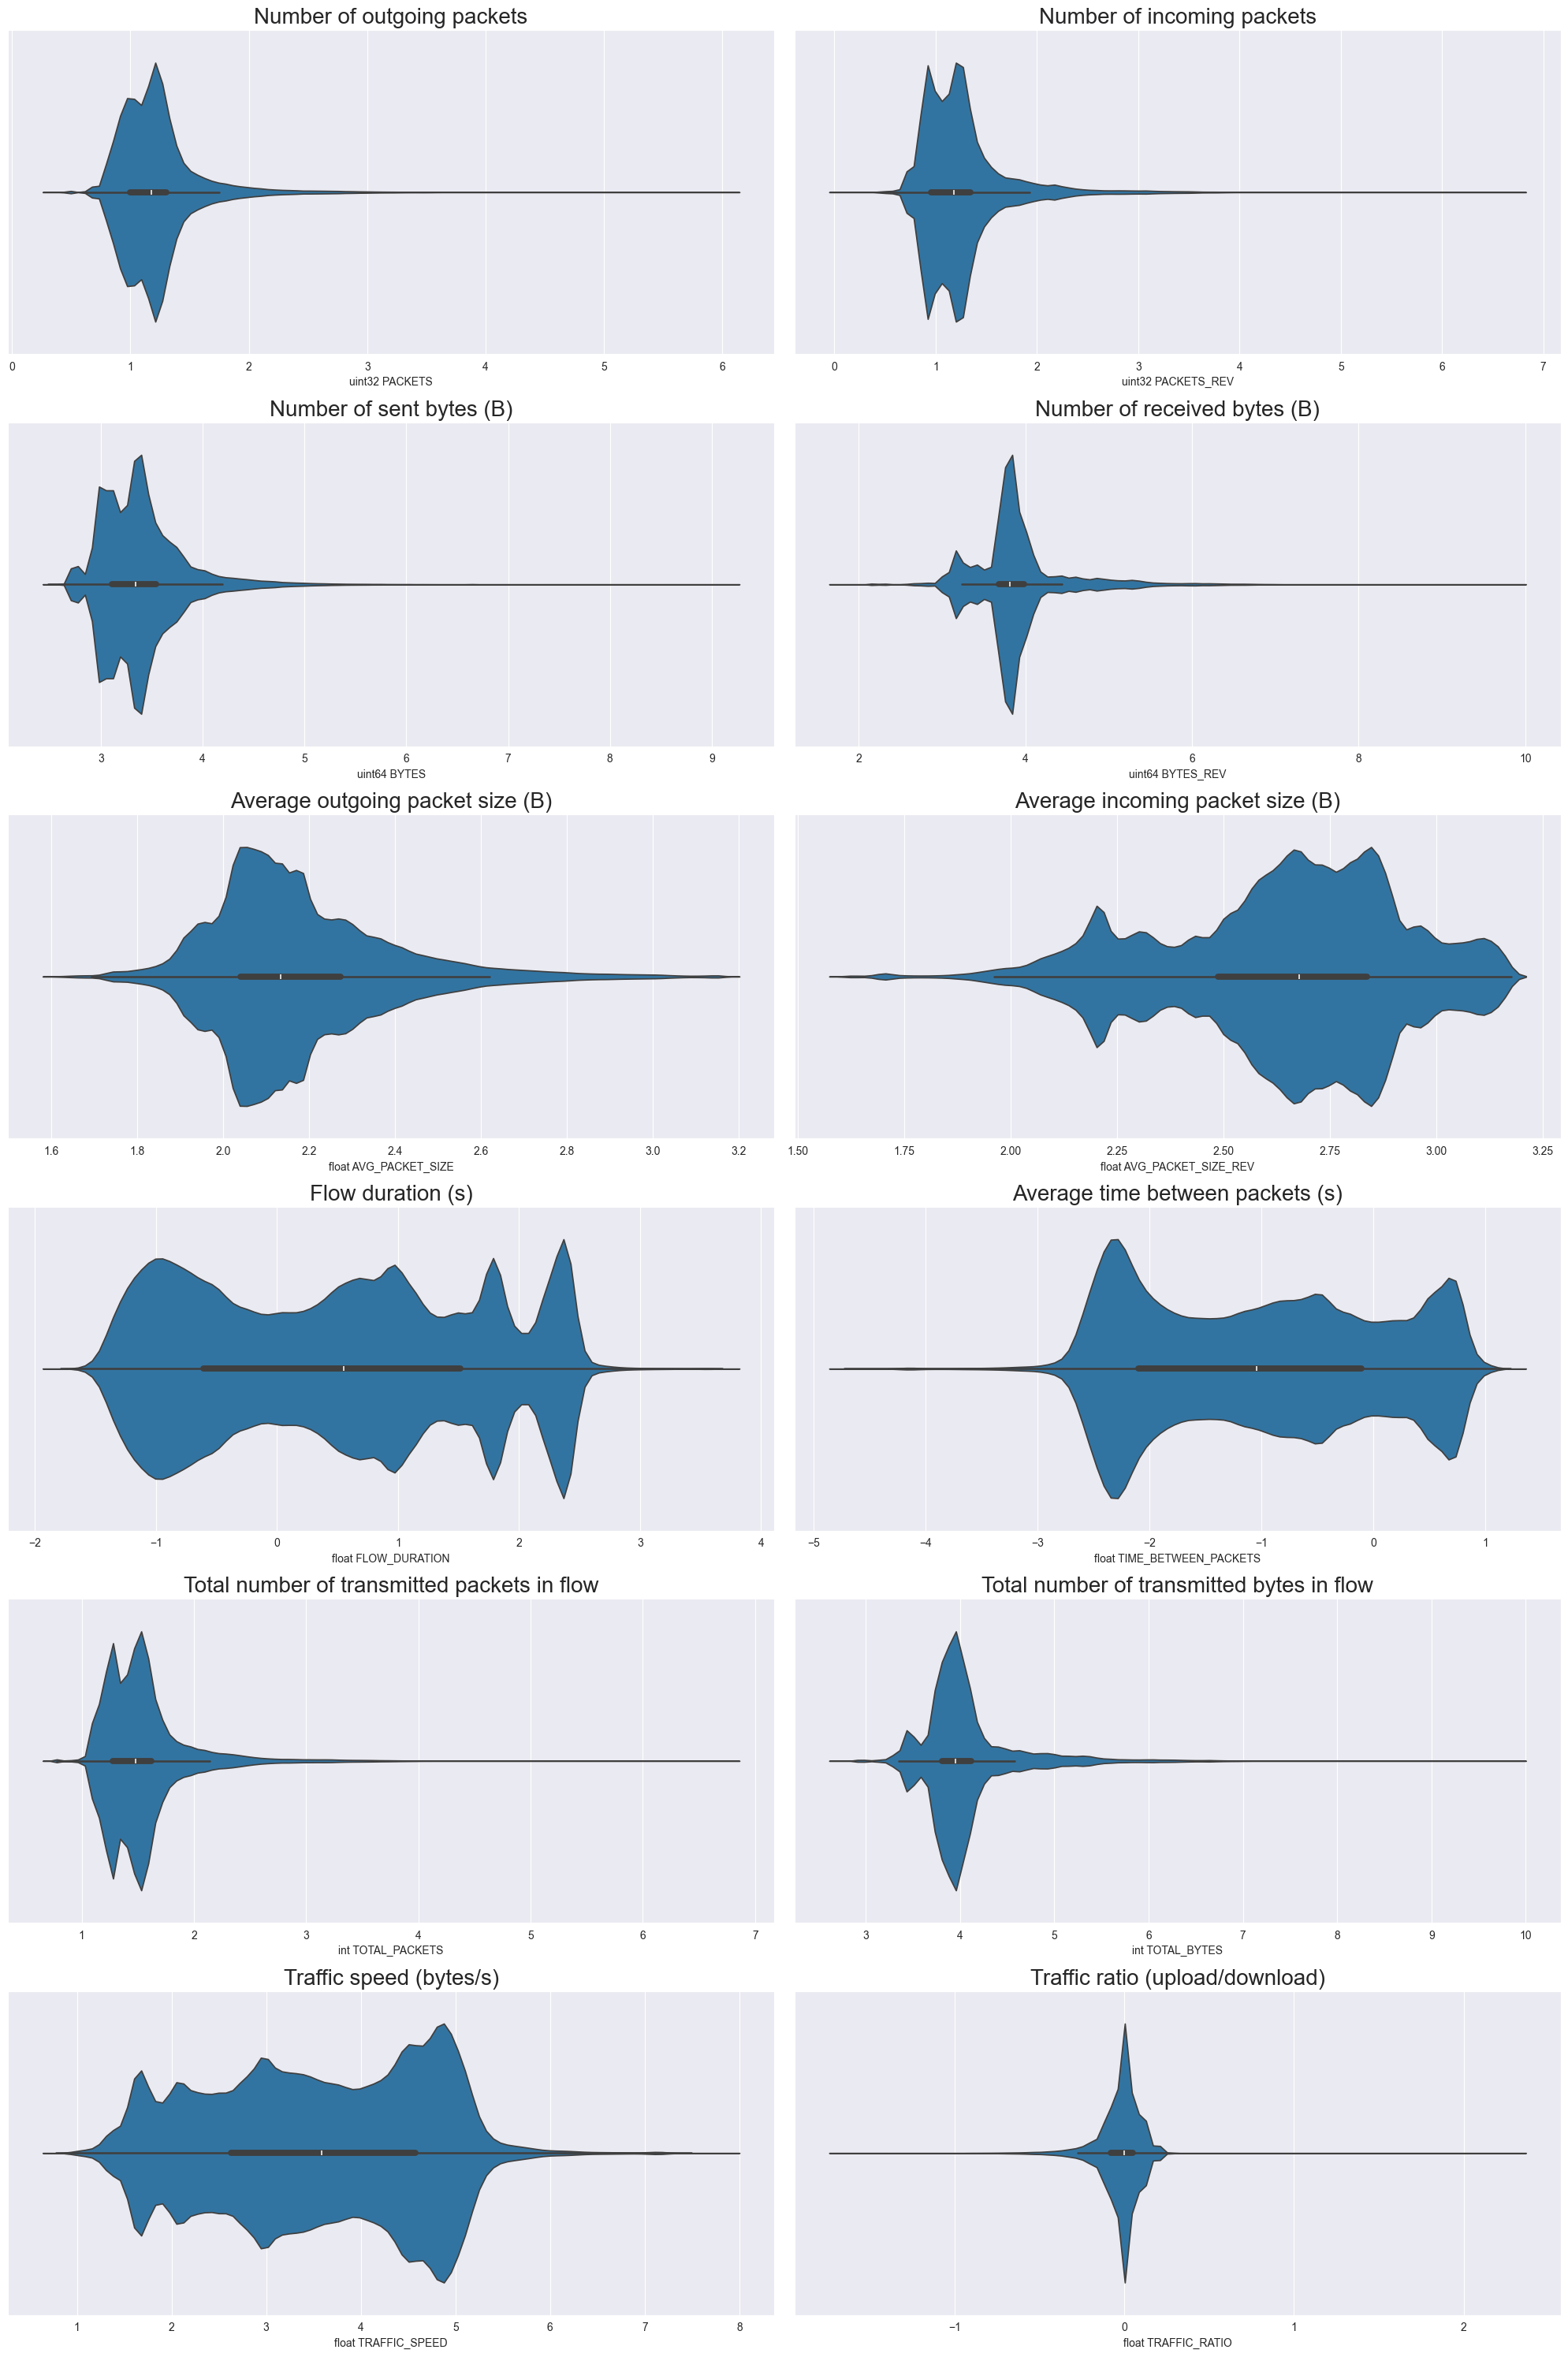

In [17]:
# List of numerical columns in your DataFrame
num_cols = [
    "uint32 PACKETS", "uint32 PACKETS_REV",
    "uint64 BYTES", "uint64 BYTES_REV",
    "float AVG_PACKET_SIZE", "float AVG_PACKET_SIZE_REV",
    "float FLOW_DURATION", "float TIME_BETWEEN_PACKETS",
    "int TOTAL_PACKETS", "int TOTAL_BYTES",
    "float TRAFFIC_SPEED", "float TRAFFIC_RATIO"
]
titles = [
    "Number of outgoing packets",
    "Number of incoming packets",
    "Number of sent bytes (B)",
    "Number of received bytes (B)",
    "Average outgoing packet size (B)",
    "Average incoming packet size (B)",
    "Flow duration (s)",
    "Average time between packets (s)",
    "Total number of transmitted packets in flow",
    "Total number of transmitted bytes in flow",
    "Traffic speed (bytes/s)",
    "Traffic ratio (upload/download)",
]
# Create a new figure and axes with a layout of 3 rows and 3 columns
fig, axs = plt.subplots(6, 2, figsize=(20, 30))

# Flatten the axes array
axs = axs.flatten()

# For each numerical column, create a violin plot on a separate subplot
for i, col in enumerate(num_cols):
    sns.violinplot(x=np.log10(df[col]), ax=axs[i])
    axs[i].set_title(titles[i], fontsize=20)

plt.tight_layout()
plt.show()

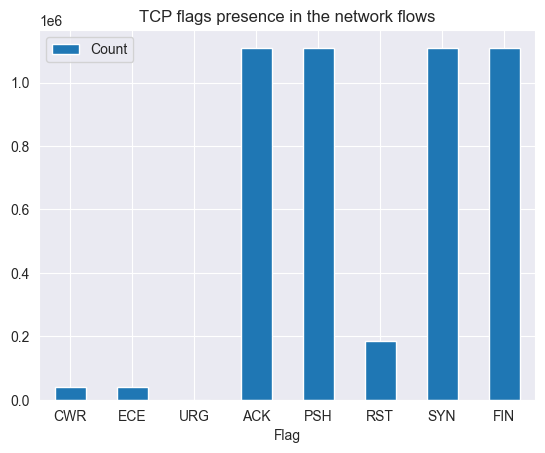

In [18]:
# Count usage of TCP flags in the dataset.
tcp_flags_dict = {
    "Flag": [
        "CWR",
        "ECE",
        "URG",
        "ACK",
        "PSH",
        "RST",
        "SYN",
        "FIN",
    ],
    "Count": [
        df[df["uint8 TCP_FLAGS"] & 0b1000_0000 != 0].shape[0],
        df[df["uint8 TCP_FLAGS"] & 0b0100_0000 != 0].shape[0],
        df[df["uint8 TCP_FLAGS"] & 0b0010_0000 != 0].shape[0],
        df[df["uint8 TCP_FLAGS"] & 0b0001_0000 != 0].shape[0],
        df[df["uint8 TCP_FLAGS"] & 0b0000_1000 != 0].shape[0],
        df[df["uint8 TCP_FLAGS"] & 0b0000_0100 != 0].shape[0],
        df[df["uint8 TCP_FLAGS"] & 0b0000_0010 != 0].shape[0],
        df[df["uint8 TCP_FLAGS"] & 0b0000_0001 != 0].shape[0],
    ],
}
tcp_flags = pd.DataFrame(tcp_flags_dict)
tcp_flags.plot.bar(x="Flag", y="Count", rot=0)
plt.title("TCP flags presence in the network flows")
plt.show()